In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:

df = pd.read_csv("iris.csv")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [3]:
df.shape


(150, 5)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


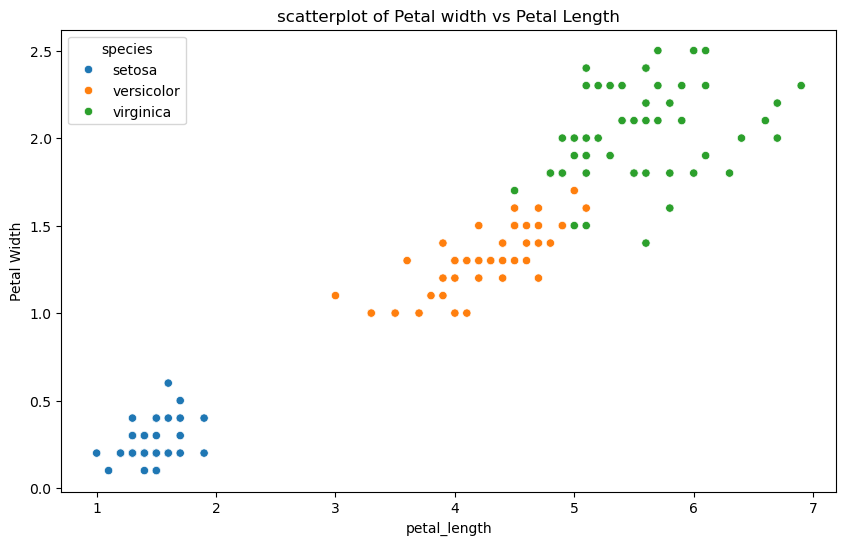

In [4]:
import matplotlib .pyplot as plt
import numpy as np
import seaborn as sns
df.columns = df.columns.str.strip()
plt.figure(figsize=(10,6))
sns.scatterplot(x = 'petal_length',y = 'petal_width', data=df,hue = 'species')
plt.ylabel("Petal Width")
plt.xlabel("petal_length")
plt.title("scatterplot of Petal width vs Petal Length")

plt.savefig(
    "iris1.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


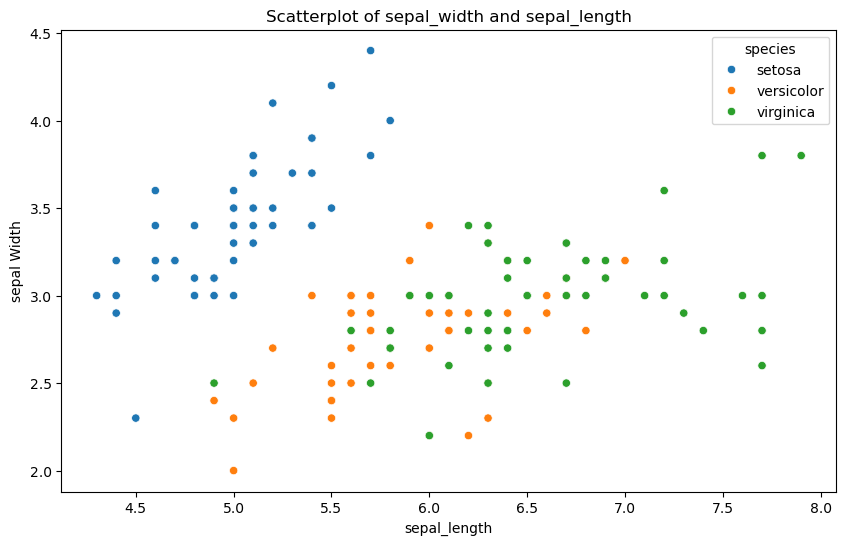

In [5]:
df.columns = df.columns.str.strip()
plt.figure(figsize=(10,6))
sns.scatterplot(x = 'sepal_length',y = 'sepal_width', data=df,hue = 'species')
plt.ylabel("sepal Width")
plt.xlabel("sepal_length")
plt.title("Scatterplot of sepal_width and sepal_length")
plt.savefig(
    "iris2.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


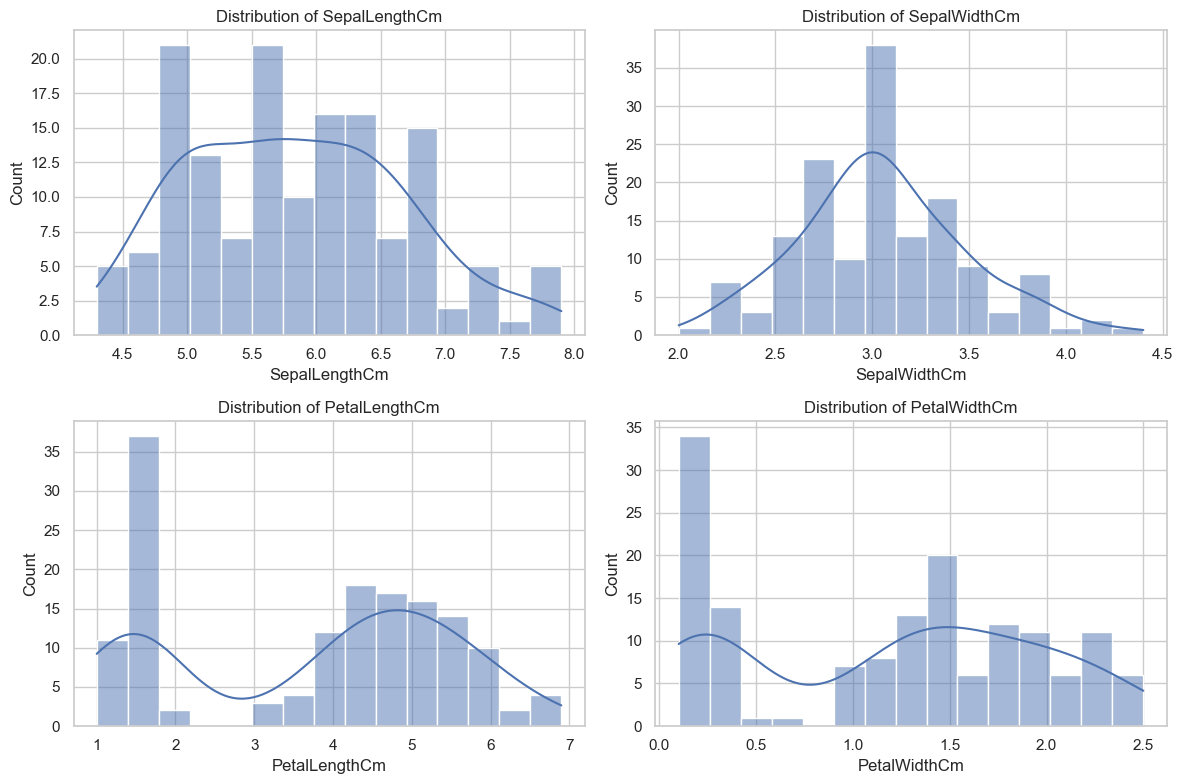

In [6]:
sns.set(style="whitegrid")

# Create a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Sepal Length
sns.histplot(
    df["sepal_length"],
    kde=True,
    bins=15,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Distribution of SepalLengthCm")
axes[0, 0].set_xlabel("SepalLengthCm")
axes[0, 0].set_ylabel("Count")

# Sepal Width
sns.histplot(
    df["sepal_width"],
    kde=True,
    bins=15,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Distribution of SepalWidthCm")
axes[0, 1].set_xlabel("SepalWidthCm")
axes[0, 1].set_ylabel("Count")

# Petal Length
sns.histplot(
    df["petal_length"],
    kde=True,
    bins=15,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Distribution of PetalLengthCm")
axes[1, 0].set_xlabel("PetalLengthCm")
axes[1, 0].set_ylabel("Count")

# Petal Width
sns.histplot(
    df["petal_width"],
    kde=True,
    bins=15,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Distribution of PetalWidthCm")
axes[1, 1].set_xlabel("PetalWidthCm")
axes[1, 1].set_ylabel("Count")

# Adjust layout
plt.tight_layout()
plt.savefig(
    "iris3.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

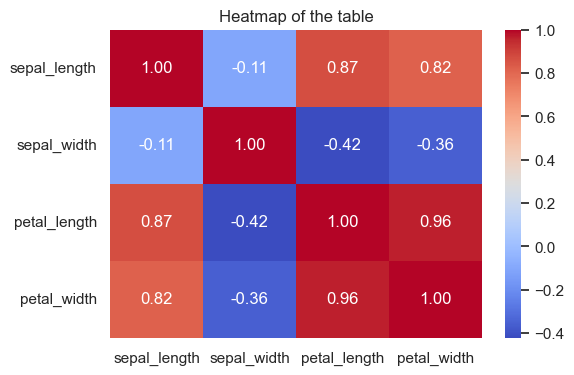

In [7]:
numeric_cols = df.select_dtypes(include=["number"]).columns
plt.figure(figsize=(6,4))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt = ".2f", cmap = "coolwarm")
plt.title("Heatmap of the table")
plt.savefig(
    "iris4.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [8]:
#petal width and height now determined as parameters, now does sepa_length matter as well?

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


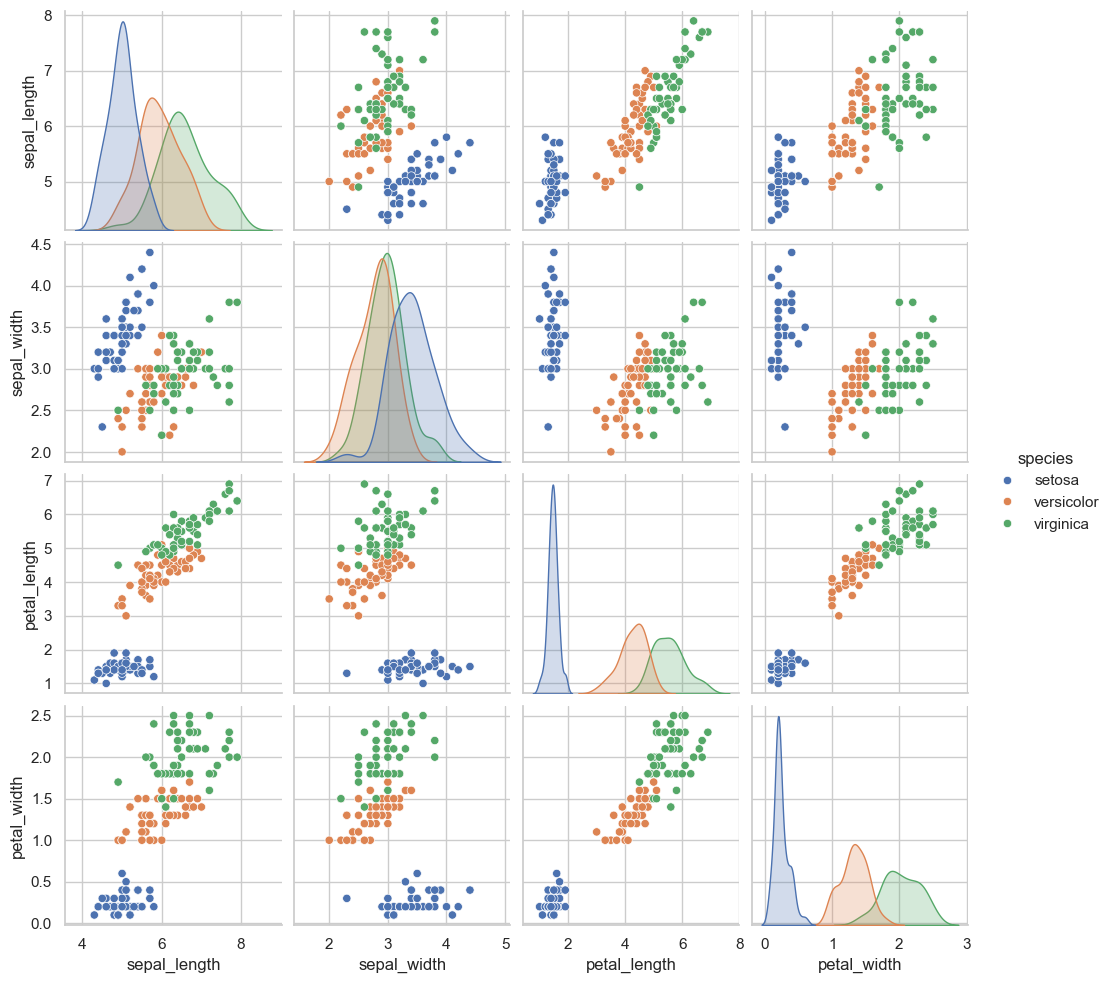

In [9]:
sns.pairplot(df, hue="species")
plt.savefig(
    "iris5.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [10]:
null_cols = df.columns[df.isnull().any()]
null_rows = df[df[null_cols].isnull().any(axis = 1)]
print("Rows with null values are: ")
print(null_rows)

Rows with null values are: 
Empty DataFrame
Columns: [sepal_length, sepal_width, petal_length, petal_width, species]
Index: []


LOAN DATASET

In [11]:
dfloan = pd.read_csv("loan_approval_dataset.csv")
dfloan



In [12]:
dfloan.head()
print("Head")
dfloan.info()
print("Info")
dfloan.describe()
print("Describe")

NameError: name 'X_train' is not defined

In [ ]:
X = df.drop("species", axis=1)
y = df["species"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)



In [ ]:
anova_selector = SelectKBest(score_func=f_classif, k=2)
X_anova_selected = anova_selector.fit_transform(X_scaled, y)

anova_scores = pd.DataFrame({
    "Feature": X.columns,
    "F-Score": anova_selector.scores_
})

print(anova_scores.sort_values(by="F-Score", ascending=False))


In [ ]:
#Thus, using ANOVA we can see that petal_length and petal_width are the most significant parameters.
# now to train the data using svc

X_train, X_test, y_train, y_test = train_test_split(
    X_anova_selected, y, test_size=0.2, random_state=42
)
grid_anova = GridSearchCV(svm, param_grid, cv=5)
grid_anova.fit(X_train, y_train)
y_pred = grid_anova.predict(X_test)
print("Best Parameters (ANOVA):", grid_anova.best_params_)
print("Accuracy:", grid_anova.best_score_)


In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=df["species"].unique(),
            yticklabels=df["species"].unique())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
plt.savefig(
    "iris6.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)